In [1]:
pip install xgboost lightgbm shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 04 — Modelado: Entrenamiento y Comparación de Modelos

Este notebook implementa la **Fase 4 (Modelado)** de CRISP-DM. Se entrenan y comparan tres algoritmos de aprendizaje automático para predecir el nivel de gravedad delictiva por zona geográfica:

- **Random Forest** — bagging con árboles paralelos
- **XGBoost** — boosting secuencial con regularización L1/L2
- **LightGBM** — boosting secuencial con crecimiento por hojas (leaf-wise)

El entrenamiento usa el conjunto balanceado (SMOTE). La evaluación usa el conjunto de test con distribución real (sin modificar).

In [2]:
# ── Instalación de dependencias ────────────────────────────────
import subprocess, sys
for pkg in ["xgboost", "lightgbm", "shap"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, confusion_matrix
)
from sklearn.preprocessing import label_binarize

import shap

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Orden y colores consistentes con el notebook anterior
CLASES_ORDEN  = ['BAJA', 'MEDIA', 'ALTA', 'CRITICA']
COLORES_CLASE = {'BAJA': '#2196F3', 'MEDIA': '#FF9800',
                 'ALTA': '#F44336', 'CRITICA': '#7B1FA2'}

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [4]:
# ── Rutas ──────────────────────────────────────────────────────
RUTA_BASE   = r"C:\Users\jhono\Downloads\Proyecto Titulación\CSV"
TRAIN_BAL   = RUTA_BASE + r"\mdi_train_balanceado.csv"
TEST        = RUTA_BASE + r"\mdi_test.csv"
TRAIN_ORIG  = RUTA_BASE + r"\mdi_train.csv"
RUTA_MODELO = RUTA_BASE + r"\modelo_final.pkl"

TARGET   = "gravedad"
FEATURES = [
    'anio',
    'mes',
    'dia_semana',
    'es_fin_de_semana',
    'hora',
    'codigo_distrito',
    'codigo_circuito',
    'codigo_subcircuito',
    'freq_subcircuito',
    'codigo_iccs',
    'macro_lugar',
    'flag_coord',
]

# Mapeo numérico → nombre de clase (orden ORDINAL corregido en notebook 03)
# 0=BAJA, 1=MEDIA, 2=ALTA, 3=CRITICA
MAPA_CLASES = {0: 'BAJA', 1: 'MEDIA', 2: 'ALTA', 3: 'CRITICA'}

---
## 1. Carga de datos

In [5]:
train_bal  = pd.read_csv(TRAIN_BAL,  sep=";", encoding="utf-8-sig")
test_df    = pd.read_csv(TEST,       sep=";", encoding="utf-8-sig")
train_orig = pd.read_csv(TRAIN_ORIG, sep=";", encoding="utf-8-sig")

X_train = train_bal[FEATURES]
y_train = train_bal[TARGET]

X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

# Train original sin balancear (para validación cruzada realista)
X_train_orig = train_orig[FEATURES]
y_train_orig = train_orig[TARGET]

print(f"Train balanceado : {X_train.shape}")
print(f"Train original   : {X_train_orig.shape}")
print(f"Test             : {X_test.shape}")
print(f"\nClases en test   : {sorted(y_test.unique())}")
print(f"Distribución test:\n{y_test.value_counts().sort_index()}")

Train balanceado : (121144, 12)
Train original   : (61488, 12)
Test             : (15372, 12)

Clases en test   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Distribución test:
gravedad
0    1528
1    7572
2    5499
3     773
Name: count, dtype: int64


---
## 2. Función de evaluación

Centraliza el cálculo de métricas para aplicar de forma uniforme a los tres modelos.

In [6]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """Entrena el modelo y retorna un diccionario con todas las métricas."""
    print(f"\n{'='*50}")
    print(f"  Entrenando: {nombre}")
    print(f"{'='*50}")

    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_te, y_pred,    average='macro', zero_division=0)
    f1   = f1_score(y_te, y_pred,        average='macro', zero_division=0)

    # AUC-ROC multiclase (One-vs-Rest)
    clases  = sorted(y_te.unique())
    y_bin   = label_binarize(y_te, classes=clases)
    auc     = roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')

    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}  (macro)")
    print(f"  Recall    : {rec:.4f}  (macro)")
    print(f"  F1        : {f1:.4f}  (macro)")
    print(f"  AUC-ROC   : {auc:.4f}  (macro OVR)")
    print(f"\nReporte por clase:")
    nombres_clases = [MAPA_CLASES[c] for c in clases]
    print(classification_report(y_te, y_pred,
                                 target_names=nombres_clases,
                                 zero_division=0))

    return {
        'modelo':    nombre,
        'objeto':    modelo,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'Accuracy':  round(acc,  4),
        'Precision': round(prec, 4),
        'Recall':    round(rec,  4),
        'F1':        round(f1,   4),
        'AUC-ROC':   round(auc,  4),
    }

resultados = []

---
## 3. Random Forest

In [7]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

res_rf = evaluar_modelo("Random Forest", rf, X_train, y_train, X_test, y_test)
resultados.append(res_rf)


  Entrenando: Random Forest
  Accuracy  : 0.8914
  Precision : 0.8406  (macro)
  Recall    : 0.8769  (macro)
  F1        : 0.8574  (macro)
  AUC-ROC   : 0.9768  (macro OVR)

Reporte por clase:
              precision    recall  f1-score   support

        BAJA       0.84      0.93      0.88      1528
       MEDIA       0.92      0.91      0.92      7572
        ALTA       0.90      0.87      0.88      5499
     CRITICA       0.71      0.80      0.75       773

    accuracy                           0.89     15372
   macro avg       0.84      0.88      0.86     15372
weighted avg       0.89      0.89      0.89     15372



---
## 4. XGBoost

In [8]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
res_xgb = evaluar_modelo("XGBoost", xgb, X_train, y_train, X_test, y_test)
resultados.append(res_xgb)


  Entrenando: XGBoost
  Accuracy  : 0.9053
  Precision : 0.8402  (macro)
  Recall    : 0.9108  (macro)
  F1        : 0.8687  (macro)
  AUC-ROC   : 0.9812  (macro OVR)

Reporte por clase:
              precision    recall  f1-score   support

        BAJA       0.88      0.99      0.93      1528
       MEDIA       0.94      0.93      0.94      7572
        ALTA       0.92      0.85      0.88      5499
     CRITICA       0.61      0.87      0.72       773

    accuracy                           0.91     15372
   macro avg       0.84      0.91      0.87     15372
weighted avg       0.91      0.91      0.91     15372



---
## 5. LightGBM

In [9]:
lgbm = LGBMClassifier(
    n_estimators=300,
    max_depth=-1,
    num_leaves=63,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
res_lgbm = evaluar_modelo("LightGBM", lgbm, X_train, y_train, X_test, y_test)
resultados.append(res_lgbm)


  Entrenando: LightGBM
  Accuracy  : 0.9148
  Precision : 0.8593  (macro)
  Recall    : 0.9023  (macro)
  F1        : 0.8784  (macro)
  AUC-ROC   : 0.9850  (macro OVR)

Reporte por clase:
              precision    recall  f1-score   support

        BAJA       0.91      0.98      0.94      1528
       MEDIA       0.94      0.94      0.94      7572
        ALTA       0.92      0.87      0.89      5499
     CRITICA       0.67      0.81      0.73       773

    accuracy                           0.91     15372
   macro avg       0.86      0.90      0.88     15372
weighted avg       0.92      0.91      0.92     15372



---
## 6. Tabla comparativa de métricas

In [10]:
metricas = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
df_res = pd.DataFrame(
    [{k: r[k] for k in ['modelo'] + metricas} for r in resultados]
).set_index('modelo')

print("\nTabla comparativa de métricas (macro-average):")
print(df_res.to_string())

# Destacar el mejor valor por métrica
print("\nMejor modelo por métrica:")
for m in metricas:
    mejor = df_res[m].idxmax()
    val   = df_res[m].max()
    print(f"  {m:<12}: {mejor}  ({val:.4f})")


Tabla comparativa de métricas (macro-average):
               Accuracy  Precision  Recall      F1  AUC-ROC
modelo                                                     
Random Forest    0.8914     0.8406  0.8769  0.8574   0.9768
XGBoost          0.9053     0.8402  0.9108  0.8687   0.9812
LightGBM         0.9148     0.8593  0.9023  0.8784   0.9850

Mejor modelo por métrica:
  Accuracy    : LightGBM  (0.9148)
  Precision   : LightGBM  (0.8593)
  Recall      : XGBoost  (0.9108)
  F1          : LightGBM  (0.8784)
  AUC-ROC     : LightGBM  (0.9850)


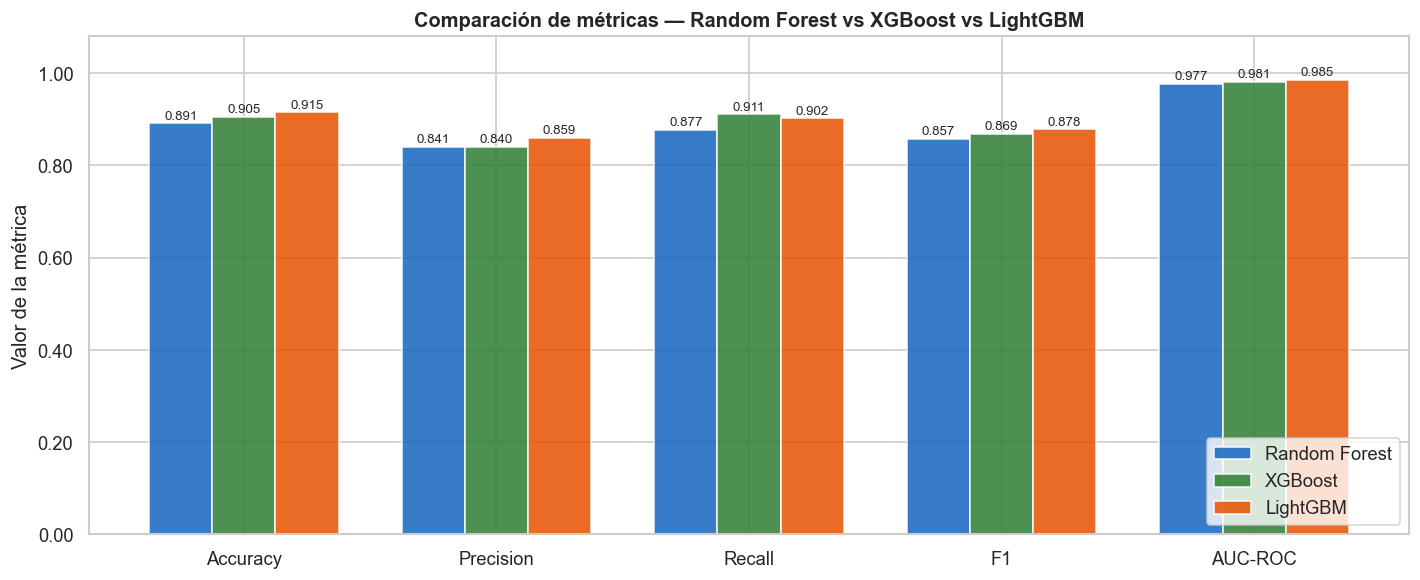

In [11]:
# ── Gráfico comparativo de métricas ───────────────────────────
colores_modelos = ['#1565C0', '#2E7D32', '#E65100']
x = np.arange(len(metricas))
ancho = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, (res, color) in enumerate(zip(resultados, colores_modelos)):
    vals = [res[m] for m in metricas]
    bars = ax.bar(x + i * ancho, vals, ancho, label=res['modelo'], color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f"{val:.3f}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + ancho)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Valor de la métrica")
ax.set_title("Comparación de métricas — Random Forest vs XGBoost vs LightGBM",
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.show()

---
## 7. Matrices de confusión

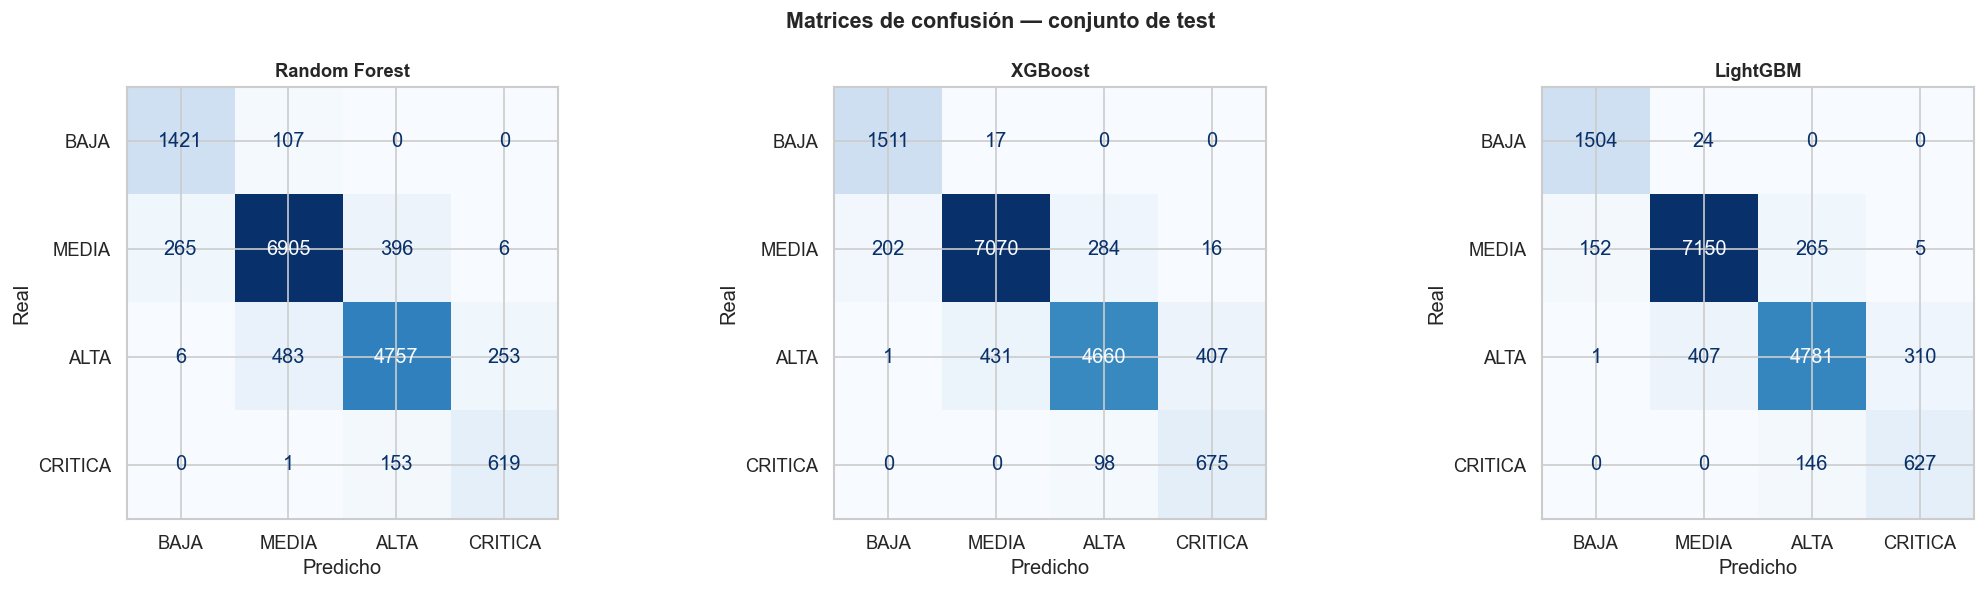

In [12]:
clases_num    = sorted(y_test.unique())
clases_nombre = [MAPA_CLASES[c] for c in clases_num]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, res in zip(axes, resultados):
    cm = confusion_matrix(y_test, res['y_pred'], labels=clases_num)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=clases_nombre)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(res['modelo'], fontsize=11, fontweight='bold')
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

fig.suptitle("Matrices de confusión — conjunto de test",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Validación cruzada estratificada (5 folds)

Se aplica sobre el conjunto de entrenamiento **sin balancear** para obtener una estimación más conservadora y realista de la generalización del modelo.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy':  'accuracy',
    'f1_macro':  'f1_macro',
    'roc_auc':   'roc_auc_ovr_weighted',
}

modelos_cv = [
    ("Random Forest", rf),
    ("XGBoost",       xgb),
    ("LightGBM",      lgbm),
]

cv_results = {}

for nombre, modelo in modelos_cv:
    print(f"\nValidación cruzada: {nombre}...")
    scores = cross_validate(
        modelo, X_train_orig, y_train_orig,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    cv_results[nombre] = scores
    print(f"  Accuracy  : {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
    print(f"  F1 macro  : {scores['test_f1_macro'].mean():.4f} ± {scores['test_f1_macro'].std():.4f}")
    print(f"  AUC-ROC   : {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")


Validación cruzada: Random Forest...
  Accuracy  : 0.8907 ± 0.0024
  F1 macro  : 0.8585 ± 0.0023
  AUC-ROC   : 0.9692 ± 0.0004

Validación cruzada: XGBoost...
  Accuracy  : 0.9188 ± 0.0020
  F1 macro  : 0.8847 ± 0.0033
  AUC-ROC   : 0.9813 ± 0.0007

Validación cruzada: LightGBM...
  Accuracy  : 0.9184 ± 0.0021
  F1 macro  : 0.8846 ± 0.0004
  AUC-ROC   : 0.9818 ± 0.0006


In [14]:
# ── Tabla resumen validación cruzada ──────────────────────────
filas_cv = []
for nombre, scores in cv_results.items():
    filas_cv.append({
        'Modelo':         nombre,
        'Accuracy μ':     round(scores['test_accuracy'].mean(), 4),
        'Accuracy σ':     round(scores['test_accuracy'].std(),  4),
        'F1 macro μ':     round(scores['test_f1_macro'].mean(), 4),
        'F1 macro σ':     round(scores['test_f1_macro'].std(),  4),
        'AUC-ROC μ':      round(scores['test_roc_auc'].mean(),  4),
        'AUC-ROC σ':      round(scores['test_roc_auc'].std(),   4),
    })

df_cv = pd.DataFrame(filas_cv).set_index('Modelo')
print("\nValidación cruzada estratificada (5 folds) — conjunto de entrenamiento sin balancear:")
print(df_cv.to_string())


Validación cruzada estratificada (5 folds) — conjunto de entrenamiento sin balancear:
               Accuracy μ  Accuracy σ  F1 macro μ  F1 macro σ  AUC-ROC μ  AUC-ROC σ
Modelo                                                                             
Random Forest      0.8907      0.0024      0.8585      0.0023     0.9692     0.0004
XGBoost            0.9188      0.0020      0.8847      0.0033     0.9813     0.0007
LightGBM           0.9184      0.0021      0.8846      0.0004     0.9818     0.0006


---
## 9. Selección del modelo final

In [15]:
# Selección basada en F1 macro (balance entre precisión y exhaustividad
# en todas las clases, incluyendo las minoritarias BAJA y CRITICA)
mejor_f1      = df_res['F1'].idxmax()
mejor_auc     = df_res['AUC-ROC'].idxmax()
mejor_acc     = df_res['Accuracy'].idxmax()

print(f"Mejor F1 macro  : {mejor_f1}  ({df_res.loc[mejor_f1, 'F1']})")
print(f"Mejor AUC-ROC   : {mejor_auc} ({df_res.loc[mejor_auc, 'AUC-ROC']})")
print(f"Mejor Accuracy  : {mejor_acc} ({df_res.loc[mejor_acc, 'Accuracy']})")

# Seleccionar el modelo con mejor F1 macro
mejor_res    = max(resultados, key=lambda r: r['F1'])
modelo_final = mejor_res['objeto']

print(f"\n>>> Modelo seleccionado: {mejor_res['modelo']} <<<")
print(f"    F1 macro : {mejor_res['F1']}")
print(f"    AUC-ROC  : {mejor_res['AUC-ROC']}")

Mejor F1 macro  : LightGBM  (0.8784)
Mejor AUC-ROC   : LightGBM (0.985)
Mejor Accuracy  : LightGBM (0.9148)

>>> Modelo seleccionado: LightGBM <<<
    F1 macro : 0.8784
    AUC-ROC  : 0.985


---
## 10. Interpretabilidad con SHAP

Los valores SHAP (Shapley Additive Explanations) cuantifican la contribución marginal de cada variable a cada predicción. Se aplican sobre el modelo seleccionado.

In [16]:
print(f"Calculando valores SHAP para {mejor_res['modelo']}...")
print("(puede tomar 1-3 minutos según el modelo)")

# Muestra representativa del test para agilizar el cálculo
X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=42)

explainer   = shap.TreeExplainer(modelo_final)
shap_values = explainer.shap_values(X_shap)

print("SHAP calculado.")

Calculando valores SHAP para LightGBM...
(puede tomar 1-3 minutos según el modelo)
SHAP calculado.


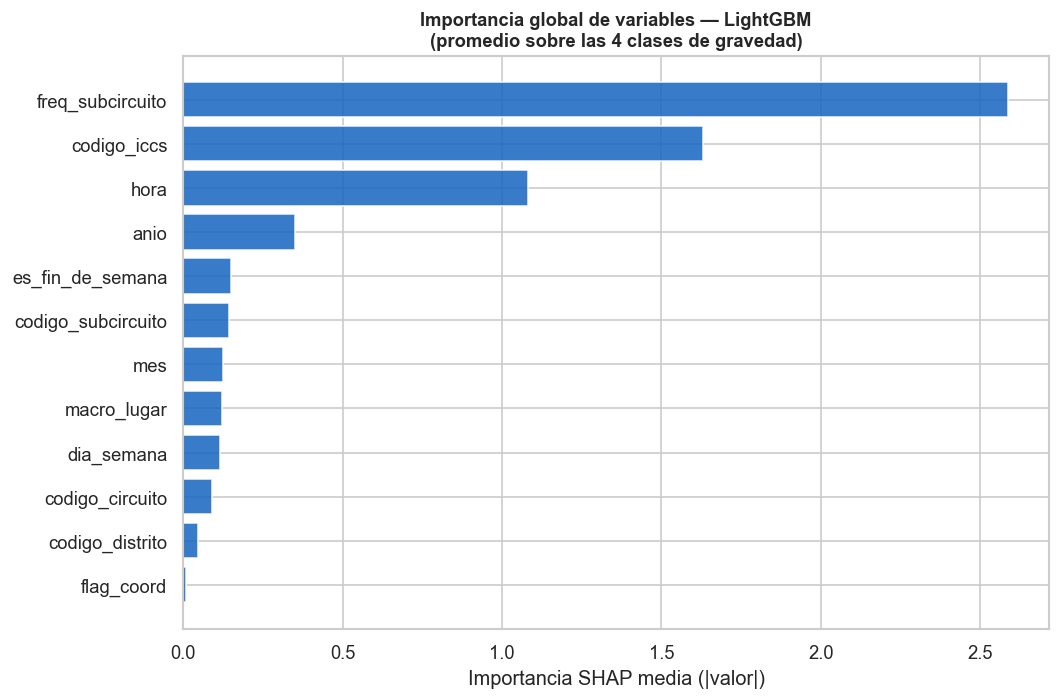


Top 5 variables más influyentes:
         Feature  Importancia
freq_subcircuito     2.586032
     codigo_iccs     1.631281
            hora     1.082492
            anio     0.350736
es_fin_de_semana     0.148606


In [17]:
# ── Importancia global de features (media del valor absoluto SHAP) ──
nombres_features = FEATURES

# Compatibilidad con SHAP nuevo (array 3D) y antiguo (lista de arrays)
if isinstance(shap_values, list):
    # Versión antigua: lista de arrays 2D, uno por clase
    shap_abs_mean = np.mean(
        [np.abs(sv).mean(axis=0) for sv in shap_values], axis=0
    )
elif shap_values.ndim == 3:
    # Versión nueva: array 3D (muestras, features, clases)
    shap_abs_mean = np.abs(shap_values).mean(axis=(0, 2))
else:
    shap_abs_mean = np.abs(shap_values).mean(axis=0)

df_shap = pd.DataFrame({
    'Feature':     nombres_features,
    'Importancia': shap_abs_mean
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(df_shap['Feature'], df_shap['Importancia'],
        color='#1565C0', alpha=0.85)
ax.set_xlabel("Importancia SHAP media (|valor|)")
ax.set_title(f"Importancia global de variables — {mejor_res['modelo']}\n"
             f"(promedio sobre las 4 clases de gravedad)",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 5 variables más influyentes:")
print(df_shap.sort_values('Importancia', ascending=False).head(5).to_string(index=False))

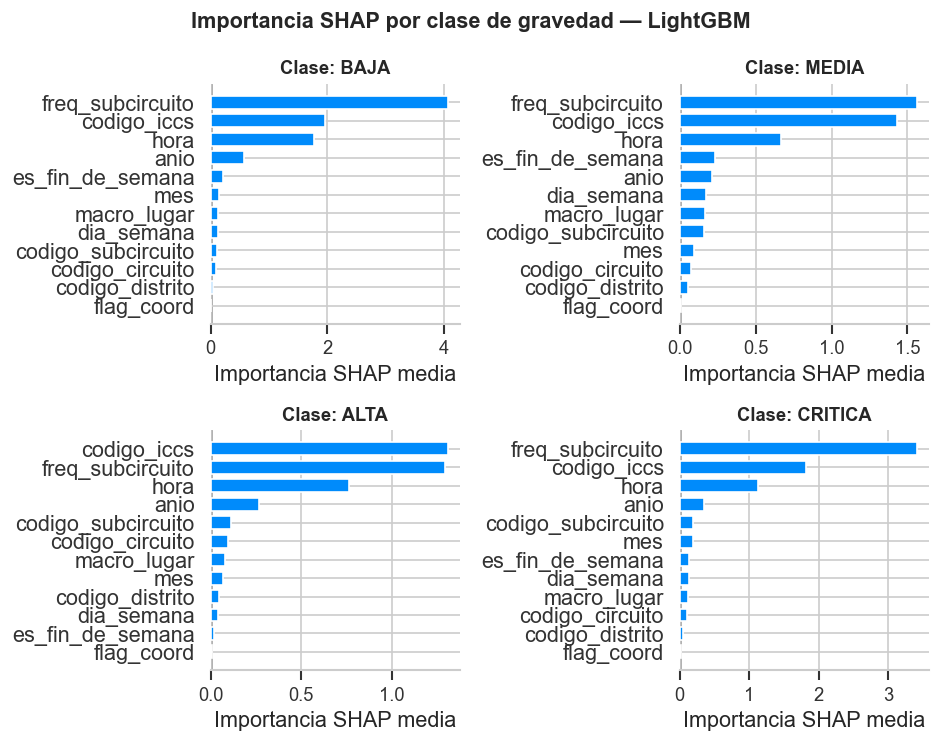

In [18]:
# ── SHAP summary plot por clase ────────────────────────────────
clases_shap   = sorted(y_test.unique())
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (ax, codigo) in enumerate(zip(axes.flatten(), clases_shap)):
    nombre_clase = MAPA_CLASES[codigo]
    plt.sca(ax)

    # Extraer valores SHAP para esta clase según formato
    if isinstance(shap_values, list):
        sv_clase = shap_values[idx]
    elif shap_values.ndim == 3:
        sv_clase = shap_values[:, :, idx]
    else:
        sv_clase = shap_values

    shap.summary_plot(
        sv_clase,
        X_shap,
        feature_names=nombres_features,
        plot_type='bar',
        show=False
    )
    ax.set_title(f"Clase: {nombre_clase}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Importancia SHAP media")

fig.suptitle(f"Importancia SHAP por clase de gravedad — {mejor_res['modelo']}",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Exportación del modelo final

In [19]:
joblib.dump(modelo_final, RUTA_MODELO)
print(f"Modelo guardado en: {RUTA_MODELO}")

# Verificación rápida: recargar y predecir
modelo_cargado = joblib.load(RUTA_MODELO)
y_verif        = modelo_cargado.predict(X_test[:5])
print(f"Verificación (primeras 5 predicciones): {[MAPA_CLASES[c] for c in y_verif]}")

print("\n" + "="*50)
print("RESUMEN FINAL")
print("="*50)
print(f"Modelo seleccionado : {mejor_res['modelo']}")
print(f"Accuracy            : {mejor_res['Accuracy']}")
print(f"Precision (macro)   : {mejor_res['Precision']}")
print(f"Recall (macro)      : {mejor_res['Recall']}")
print(f"F1 (macro)          : {mejor_res['F1']}")
print(f"AUC-ROC (macro OVR) : {mejor_res['AUC-ROC']}")
print(f"Archivo exportado   : modelo_final.pkl")

Modelo guardado en: C:\Users\jhono\Downloads\Proyecto Titulación\CSV\modelo_final.pkl
Verificación (primeras 5 predicciones): ['BAJA', 'ALTA', 'MEDIA', 'ALTA', 'MEDIA']

RESUMEN FINAL
Modelo seleccionado : LightGBM
Accuracy            : 0.9148
Precision (macro)   : 0.8593
Recall (macro)      : 0.9023
F1 (macro)          : 0.8784
AUC-ROC (macro OVR) : 0.985
Archivo exportado   : modelo_final.pkl
